# Finformer: Complete Walkthrough - From Concept to Trading Strategy

Welcome to the **Finformer** walkthrough! This notebook takes you from zero to a working AI trading model.

### What is the goal?
We want to predict the future returns of a stock market index (like the CSI 300) based on its past performance.

### What makes Finformer special?
Financial markets are not always the same. Sometimes they are calm, and sometimes they are "volatile" (crazy/unpredictable). Standard AI models treat all time periods the same. **Finformer** uses a **Volatility-Aware Attention (VAA)** mechanism that changes how it "listens" to the past based on current market volatility.

### Roadmap
1. **Part A** - The Concept: Stock Prediction & AI 101
2. **Part B** - The Theory: Understanding Transformers & Attention
3. **Part C** - The Practice: Running the Finformer Project

---
# Part A: The Concept - Stock Prediction & AI 101

If you have never written a line of code or looked at a neural network, **this is the place to start.**

### The Goal
Imagine you want to buy a stock today. You want to know: **Will the price go UP or DOWN tomorrow?**
- If we predict it goes **UP**, we buy.
- If we predict it goes **DOWN**, we sell (or don't buy).

### The Problem
The stock market is **chaotic**.
- Sometimes it's calm and follows trends (like a sunny day).
- Sometimes it's "volatile" and crazy (like a thunderstorm).

Standard AI models treat every day like a sunny day. **Our model (Finformer)** is smart enough to know when it's storming and adjust its strategy.

## A.1 Setting Up Our Toolbox

In [1]:
# 'pandas' is like Excel for Python. It lets us work with tables of data.
import pandas as pd

# 'numpy' is for mathematical operations on arrays.
import numpy as np

# 'matplotlib' is our drawing kit. It lets us make charts and graphs.
import matplotlib.pyplot as plt

# 'seaborn' makes nicer heatmaps and statistical plots.
import seaborn as sns

# 'os' helps us find files on your computer.
import os

print("Toolbox loaded! We are ready to work.")

Toolbox loaded! We are ready to work.


## A.2 Loading the Data
We need historical data to learn from. We are using the **CSI 300 Index**, which tracks the top 300 companies in China (similar to the S&P 500 in the US).

We will load a `.csv` file, which is just a text version of an Excel spreadsheet.

In [2]:
# Define where the file is located. '..' means "go up one folder".
data_path = os.path.join('..', 'data', 'raw', 'csi300_daily.csv')

if not os.path.exists(data_path):
    print("Error: Data file not found. Please run the download script first.")
else:
    # Load the data into a "DataFrame" (think of it as a smart table)
    df = pd.read_csv(data_path)
    
    # Convert the 'trade_date' column to actual Date objects
    df['trade_date'] = pd.to_datetime(df['trade_date'])
    
    # Sort the data from oldest to newest
    df = df.sort_values('trade_date').reset_index(drop=True)
    
    print(f"Success! We have {len(df)} days of stock market history.")
    display(df.head())

Success! We have 3643 days of stock market history.


,trade_date,open,high,low,close,volume
0,2010-01-04,3592.468,3597.748,3535.229,3535.229,6610108000
1,2010-01-05,3545.186,3577.526,3497.661,3564.038,8580964000
2,2010-01-06,3558.700,3588.832,3541.173,3541.727,7847312500
3,2010-01-07,3543.160,3558.556,3452.769,3471.456,8035004000
4,2010-01-08,3456.908,3482.083,3426.698,3480.130,6079025200


### Visualizing the Market
Numbers in a table are hard to read. Let's draw a line chart.

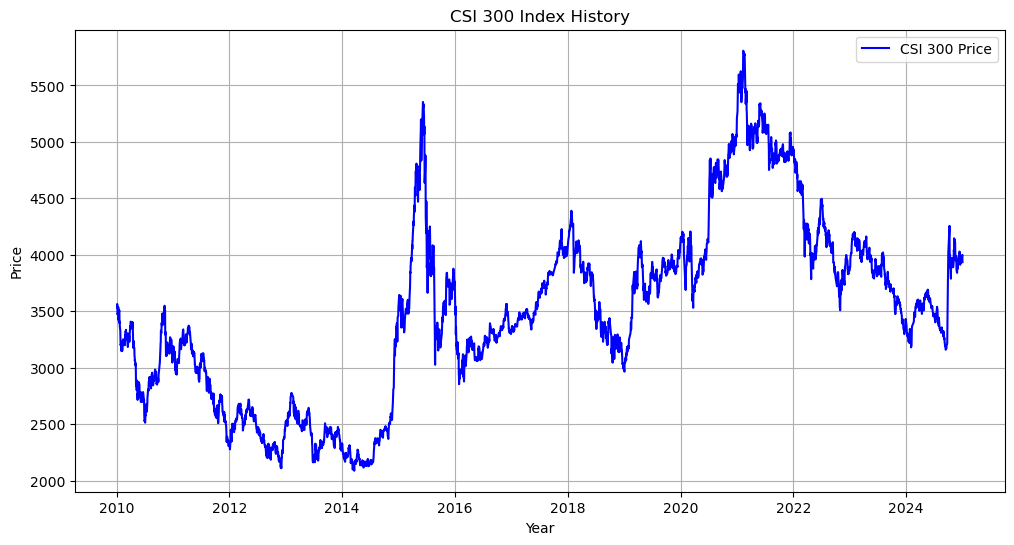

In [3]:
plt.figure(figsize=(12, 6))
plt.plot(df['trade_date'], df['close'], label='CSI 300 Price', color='blue')
plt.title('CSI 300 Index History')
plt.xlabel('Year')
plt.ylabel('Price')
plt.grid(True)
plt.legend()
plt.show()

## A.3 Feature Engineering: Making the Data "Smart"
Raw prices aren't enough. Imagine trying to drive a car just by looking at the speedometer. You also need to know:
- **How fast are you accelerating?** (Momentum)
- **Is the road bumpy?** (Volatility)

We calculate **Features** (Indicators) to give the AI more context.

Key features include:
- **Moving Averages (MA)**: Smoothing the price to see trends.
- **RSI**: Identifying if the market is "overbought" or "oversold".
- **GARCH Volatility**: A mathematical model that estimates how "risky" the market is right now.

### Concept: Volatility (The "Bumpiness")
**Volatility** measures how much the price is jumping around.
- **Low Volatility**: Price moves slowly (calm).
- **High Volatility**: Price swings wildly (panic/euphoria).

Our model **needs** to know this to change its attention!

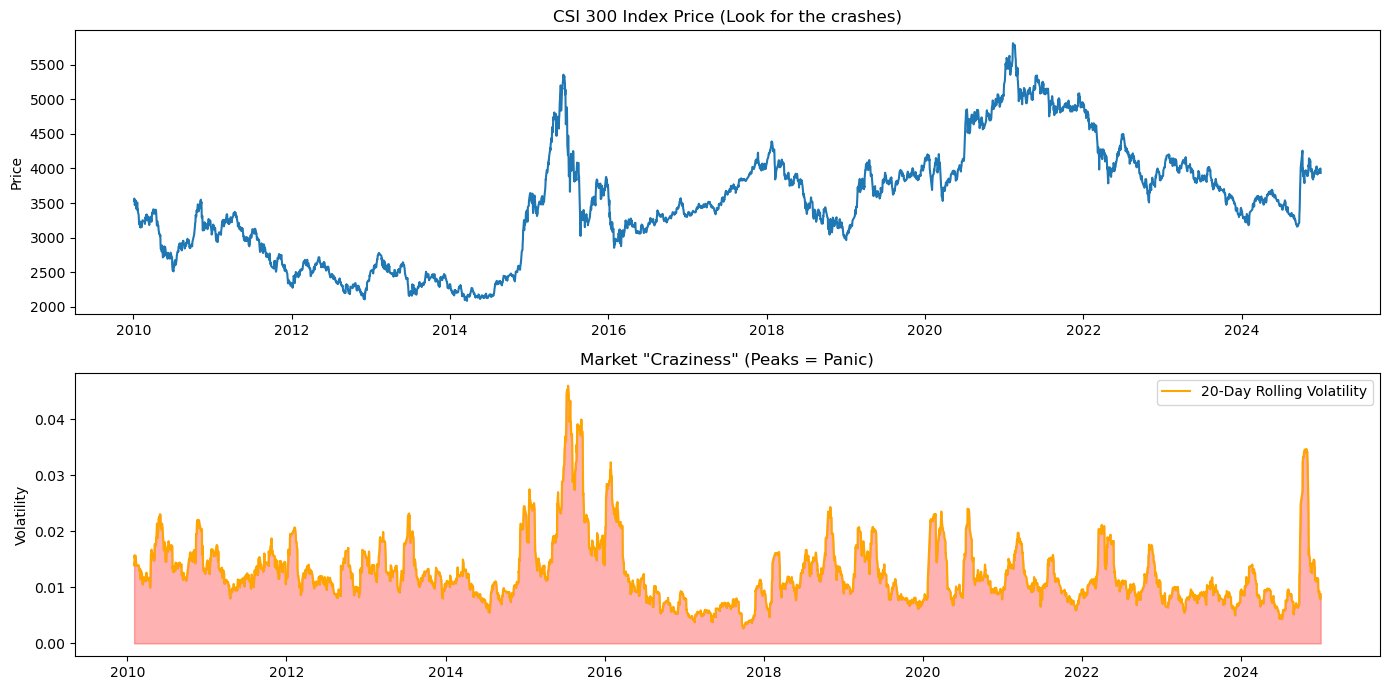

In [4]:
# Calculate 'Returns': The percentage change from yesterday to today
df['returns'] = df['close'].pct_change()

# Calculate 'Volatility': The standard deviation (craziness) over the last 20 days
df['volatility_20d'] = df['returns'].rolling(window=20).std()

# Visualize Price and Volatility together
plt.figure(figsize=(14, 7))

plt.subplot(2, 1, 1)
plt.plot(df['trade_date'], df['close'])
plt.title('CSI 300 Index Price (Look for the crashes)')
plt.ylabel('Price')

plt.subplot(2, 1, 2)
plt.fill_between(df['trade_date'], df['volatility_20d'], color='red', alpha=0.3)
plt.plot(df['trade_date'], df['volatility_20d'], color='orange', label='20-Day Rolling Volatility')
plt.title('Market "Craziness" (Peaks = Panic)')
plt.ylabel('Volatility')
plt.legend()
plt.tight_layout()
plt.show()

## A.4 The "Secret Sauce": Volatility-Aware Attention (VAA)

### The Driver Analogy
Imagine you are driving an autonomous car.
1. **Sunny Day (Low Volatility):** The car looks far ahead at the horizon. It plans for the long term.
2. **Stormy Night (High Volatility):** The car ignores the horizon. It focuses **intensely** on the few meters right in front of it.

**Standard AI** always looks at the horizon, even in a storm. It crashes.
**Finformer (Our AI)** checks the weather (Volatility). If it's stormy, it shifts its focus to the immediate chaos.

### How do we know if it works?
We don't just look at error numbers. We simulate a **Trading Strategy**.

- **Hit Rate**: Did we guess the direction (Up/Down) correctly?
- **Sharpe Ratio**: A finance term for "Risk vs. Reward".
    - If you make \$100 but risk losing your house, that's a **bad** Sharpe Ratio.
    - If you make \$10 with zero risk, that's a **good** Sharpe Ratio.

---
# Part B: The Theory - Understanding Transformers & Attention

In Part A, we learned *why* we are doing this. Now we will learn *how* it works.

If you have ever wondered: **"How does ChatGPT actually read?"**, this section will explain it.

## B.1 What is a Transformer?

Imagine you are reading this sentence:
> "The **bank** of the river was muddy, but the **bank** refused the loan."

How do you know the first 'bank' is a piece of land and the second is a financial institution?
**You look at the surrounding words.**

A **Transformer** is an AI architecture that does exactly this. It uses a mechanism called **"Attention"** to look at all parts of a sequence (words in a sentence or prices in a stock chart) and decide which ones are important for understanding the current point.

### The "Spotlight" Concept
Think of Attention as a **Spotlight**:
- When the AI looks at a specific day's price, it shines a spotlight on previous days.
- If yesterday was a massive crash, the spotlight on "Yesterday" will be very bright.
- If three weeks ago was just a normal day, the spotlight on that day will be dim.

## B.2 Visualizing Attention with Code
Let's simulate how an AI "looks" at data. We'll create a fake stock price series and see how a "Spotlight" might move.

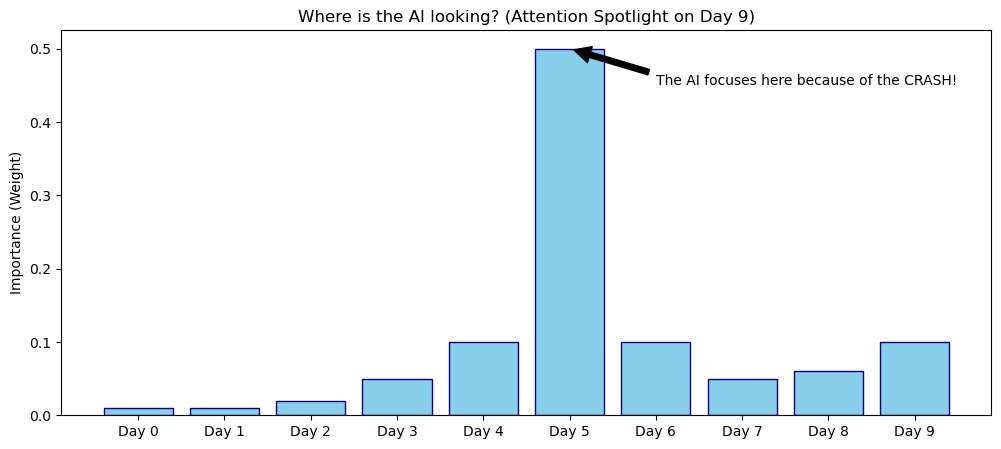

In [5]:
# Create fake stock data: A steady rise with one sudden crash
prices = [100, 101, 102, 103, 102, 90, 91, 92, 93, 94]  # Day 5 (value 90) is the crash!
days = [f"Day {i}" for i in range(len(prices))]

# Simulate "Attention weights"
# The AI is sitting on Day 9 (price 94) looking back at history.
# It cares MOST about the crash (Day 5) because that was a HUGE event.
attention_on_day_9 = [0.01, 0.01, 0.02, 0.05, 0.10, 0.50, 0.10, 0.05, 0.06, 0.10]
# Notice Day 5 has 0.50 (50% importance)!

plt.figure(figsize=(12, 5))
plt.bar(days, attention_on_day_9, color='skyblue', edgecolor='navy')
plt.title("Where is the AI looking? (Attention Spotlight on Day 9)")
plt.ylabel("Importance (Weight)")
plt.annotate('The AI focuses here because of the CRASH!', xy=(5, 0.5), xytext=(6, 0.45),
             arrowprops=dict(facecolor='black', shrink=0.05))
plt.show()

## B.3 Why is Finance Harder than Text?

In ChatGPT, words have fixed meanings (e.g., "Apple" is usually a fruit or a company).
In Finance:
1. **Numbers are Continuous**: A price of 3000 isn't a "word"; it's a value.
2. **Regimes Change**: A 1% drop on a calm day is "Big News." A 1% drop during a market crash is "Nothing."
3. **Stationarity**: The stock market is "non-stationary," meaning the rules of the game change over time.

### The Problem with Standard Transformers
Standard Transformers treat every "Attention Spotlight" the same way. But in a **Volatile (Crazy)** market, you should probably focus more on the **very recent past** because old news becomes irrelevant quickly. In a **Calm** market, you should look at the **long-term trend**.

## B.4 Our Solution: Volatility-Aware Attention (VAA)

**Finformer** introduces a "thermostat" for the spotlight.
- When **Volatility is High**: The thermostat turns up the heat, making the spotlight very "sharp" and focused on recent events.
- When **Volatility is Low**: The thermostat cools down, making the spotlight "wide" and blurred across many days.

### Mathematical Intuition (Simplified)
Standard Attention uses a formula involving `Softmax`.
**Softmax** takes a list of numbers and turns them into probabilities that sum to 100%.

We introduce a **Temperature Scale**.
- **Low Temp**: Makes the biggest number HUGE and the others tiny (Focus).
- **High Temp**: Makes all numbers roughly equal (Blur).

Let's visualize how this "Temperature" changes the spotlight.

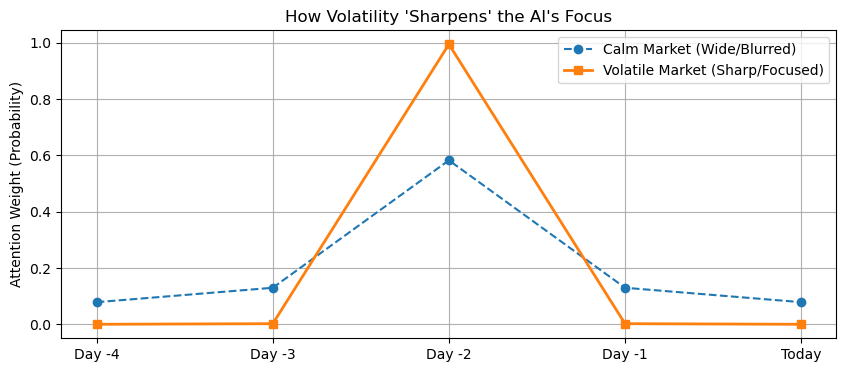

In [6]:
def softmax(x, temperature=1.0):
    """The formula AI uses to decide probabilities."""
    e_x = np.exp(x / temperature)
    return e_x / e_x.sum()

# Imagine the AI has "scores" for 5 days.
# Day 2 is the most interesting (score 5).
raw_scores = np.array([1, 2, 5, 2, 1])

# Calm Market (High Temperature = 2.0) -> Blurred spotlight
calm_attention = softmax(raw_scores, temperature=2.0)

# Volatile Market (Low Temperature = 0.5) -> Sharp spotlight
volatile_attention = softmax(raw_scores, temperature=0.5)

plt.figure(figsize=(10, 4))
plt.plot(calm_attention, label='Calm Market (Wide/Blurred)', marker='o', linestyle='--')
plt.plot(volatile_attention, label='Volatile Market (Sharp/Focused)', marker='s', linewidth=2)
plt.title("How Volatility 'Sharpens' the AI's Focus")
plt.ylabel("Attention Weight (Probability)")
plt.legend()
plt.xticks(range(5), ["Day -4", "Day -3", "Day -2", "Day -1", "Today"])
plt.grid(True)
plt.show()

## B.5 Implementing the VAA Layer (Simplified)

Here is how the code looks. We use a small "Vol-Net" (a tiny neural network) to decide the spotlight temperature.
It takes 4 volatility scales as input (5-day, 10-day, 20-day, 60-day) - like checking the weather on 4 different apps to be sure.

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class VolNet(nn.Module):
    """A tiny neural network that predicts the attention temperature."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(4, 16),  # Layer 1: Learn features from 4 volatility scales
            nn.ReLU(),         # Activation: Make it non-linear
            nn.Linear(16, 1),  # Output: Predict ONE number (Temperature)
            nn.Sigmoid()       # Squash it between 0 and 1
        )

    def forward(self, vol_features):
        # Maps 0-1 output to a useful scale, e.g., 0.5 to 2.0
        return self.net(vol_features) * 1.5 + 0.5

print("The 'Thermostat' network is defined in PyTorch!")

The 'Thermostat' network is defined in PyTorch!


## B.6 The Attention Map

The ultimate way to analyze a Transformer is the **Attention Map**. It's a heatmap showing exactly which days in history the AI "looked at" to make today's prediction.

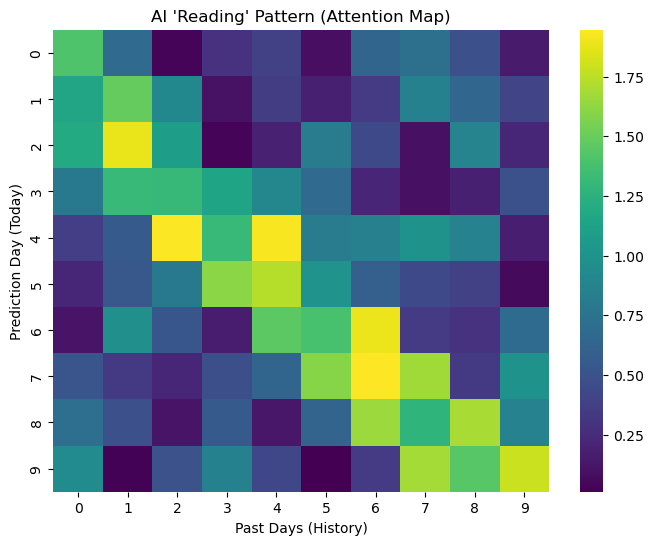

In [8]:
# Dummy Attention Map for 10 days
# Rows are "Today" and columns are "History"
map_data = np.random.rand(10, 10)

# Make the diagonal and recent days "brighter" (higher values)
for i in range(10):
    map_data[i, max(0, i-2):i+1] += 1.0

plt.figure(figsize=(8, 6))
sns.heatmap(map_data, cmap='viridis', annot=False)
plt.title("AI 'Reading' Pattern (Attention Map)")
plt.xlabel("Past Days (History)")
plt.ylabel("Prediction Day (Today)")
plt.show()

### Summary of Part B

1. **Transformer**: An AI that "reads" sequences by focusing (Attention) on relevant parts.
2. **The Problem**: Stock markets change speeds. Calm vs. Panic.
3. **The Innovation (VAA)**: We use a separate AI to measure "Market Craziness" and adjust the Transformer's focus automatically.
4. **The Goal**: By sharpening focus during panic and broadening it during calm, the Finformer makes more accurate predictions than a standard AI.

---
# Part C: The Practice - Running the Finformer Project

In Parts A and B, we learned the concepts and theory. Now we roll up our sleeves.
This section runs the **actual code** used in the `Finformer` project.

We will:
1. **Ingest Data**: Load real stock market history.
2. **Process Data**: Turn prices into math (Tensors).
3. **Build Model**: Create the VAA Transformer.
4. **Train**: Teach the AI using a "Training Loop".
5. **Evaluate**: See if we made any virtual money.

## C.1 Setup & Imports
We import the tools and add `..` to the path so Python can find our custom code in the `data/` and `models/` folders.

In [9]:
import sys
from torch.utils.data import DataLoader

# Add project root to path (so we can say 'from models import ...')
sys.path.append(os.path.abspath('..'))

# Import our custom modules (the files you see in the sidebar)
from data.features import feature_engineering_pipeline
from data.dataset import FinancialDataset
from models.proposed.vaa_transformer import VAATransformer
from scripts.metrics import calculate_metrics

print("All project modules imported! We are ready to code.")

All project modules imported! We are ready to code.


## C.2 Loading the Raw Data
We start with the raw `.csv` file - just a list of Date, Open, High, Low, Close, Volume.

In [10]:
raw_data_path = os.path.join('..', 'data', 'raw', 'csi300_daily.csv')

if os.path.exists(raw_data_path):
    df = pd.read_csv(raw_data_path)
    df['trade_date'] = pd.to_datetime(df['trade_date'])
    df = df.sort_values('trade_date').reset_index(drop=True)

    print(f"Loaded {len(df)} days of CSI 300 data.")
    display(df.tail())  # Show the most recent days
else:
    print("Data missing! Run 'python data/download.py' in your terminal.")

Loaded 3643 days of CSI 300 data.


,trade_date,open,high,low,close,volume
3638,2024-12-25,3987.956,4007.763,3969.477,3985.629,15939074700
3639,2024-12-26,3981.732,3991.533,3965.546,3987.480,14342528600
3640,2024-12-27,3987.019,4007.131,3970.937,3981.031,16926866600
3641,2024-12-30,3976.700,4005.778,3976.700,3999.055,16461248500
3642,2024-12-31,3995.871,4004.346,3934.911,3934.911,18392839700


## C.3 Feature Engineering Pipeline
The AI can't just look at "Price". It needs **Indicators**.
We use our custom function `feature_engineering_pipeline` which adds:
1. **Technical Indicators**: MA, RSI, MACD (using `talib`)
2. **Volatility Features**: Rolling std, Parkinson, and GARCH(1,1).
3. **Returns**: Multi-scale returns.

In [11]:
try:
    print("Calculating features... (This might take a moment)")
    df_processed = feature_engineering_pipeline(df)
    
    # Drop the first few rows (NaN) because Moving Averages need history to start
    df_processed = df_processed.dropna().reset_index(drop=True)
    
    print(f"Features created! New shape: {df_processed.shape}")
    print("Columns:", df_processed.columns.tolist())
    
except Exception as e:
    print(f"Error: {e}")
    print("Did you install ta-lib? 'conda install -c conda-forge ta-lib'")

Calculating features... (This might take a moment)
Features created! New shape: (3583, 40)
Columns: ['trade_date', 'open', 'high', 'low', 'close', 'volume', 'MA5', 'MA10', 'MA20', 'MA60', 'EMA12', 'EMA26', 'RSI14', 'MACD', 'MACD_signal', 'MACD_hist', 'BB_upper', 'BB_lower', 'BB_width', 'ATR14', 'ADX14', 'CCI14', 'WILLR14', 'OBV', 'VWAP', 'STOCH_K', 'STOCH_D', 'pct_chg', 'vol_5d', 'vol_10d', 'vol_20d', 'vol_60d', 'vol_parkinson', 'vol_gk', 'vol_garch', 'ret_1d', 'ret_5d', 'ret_20d', 'log_ret', 'vol_ratio_20']


## C.4 Turning Data into Sequences (Tensors)

### Concept: The Rolling Window
A Transformer doesn't look at one day. It looks at a **Sequence** (e.g., the last 30 days).
We need to slide a window over our data to create thousands of "30-day snippets".

- **Input (X)**: Days 1 to 30
- **Target (Y)**: Day 31 (The answer we want to predict)

In [12]:
# 1. Pick the best features
feature_cols = ['MA5', 'MA10', 'RSI14', 'MACD', 'BB_width', 'ATR14']
vol_cols = ['vol_5d', 'vol_10d', 'vol_20d', 'vol_60d']  # The 4 scales for VAA
target_col = 'ret_1d'  # We want to predict tomorrow's return

# 2. Extract values as numpy arrays
X = df_processed[feature_cols].values
Y = df_processed[target_col].values
Vol = df_processed[vol_cols].values

# 3. Use our Custom Dataset Class (handles the sliding window)
seq_len = 30  # Look back 30 days
dataset = FinancialDataset(X, Y, Vol, seq_len=seq_len)

# 4. Inspect one sample
x_sample, vol_sample, y_sample = dataset[0]
print(f"Sequence Shape (Days, Features): {x_sample.shape}")
print(f"Volatility Features Shape: {vol_sample.shape}")
print(f"Target (Next Day Return): {y_sample.item():.4f}")

Sequence Shape (Days, Features): torch.Size([30, 6])
Volatility Features Shape: torch.Size([30, 4])
Target (Next Day Return): -0.0033


## C.5 The Brain: VAATransformer
Now we create the model. It expects:
- **Input Size**: Number of features (e.g., 6)
- **d_model**: Size of its internal "brain" (e.g., 64 neurons)
- **n_heads**: Number of "attention spotlights" (e.g., 4)

In [13]:
input_dim = len(feature_cols)

# Initialize the model
model = VAATransformer(input_size=input_dim, d_model=64, n_heads=4, n_layers=2)

# Simulate a forward pass
dummy_x = torch.randn(8, 30, input_dim)
dummy_vol = torch.randn(8, 30, 4)
output = model(dummy_x, dummy_vol)

print(f"Model Output Shape (Batch, Prediction): {output.shape}")
print("\nModel Architecture:")
print(model)

Model Output Shape (Batch, Prediction): torch.Size([8, 1])

Model Architecture:
VAATransformer(
  (embedding): Linear(in_features=6, out_features=64, bias=True)
  (layers): ModuleList(
    (0-1): 2 x VAAEncoderLayer(
      (self_attn): VolatilityAwareAttention(
        (W_Q): Linear(in_features=64, out_features=64, bias=True)
        (W_K): Linear(in_features=64, out_features=64, bias=True)
        (W_V): Linear(in_features=64, out_features=64, bias=True)
        (W_O): Linear(in_features=64, out_features=64, bias=True)
        (vol_net): Sequential(
          (0): Linear(in_features=4, out_features=16, bias=True)
          (1): ReLU()
          (2): Linear(in_features=16, out_features=4, bias=True)
          (3): Sigmoid()
        )
      )
      (linear1): Linear(in_features=64, out_features=2048, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (linear2): Linear(in_features=2048, out_features=64, bias=True)
      (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine

## C.6 The Training Loop (Learning)

This is where the magic happens.
1. **Forward Pass**: The model guesses.
2. **Loss Calculation**: We check how wrong it was (MSE Loss).
3. **Backward Pass**: We calculate *why* it was wrong (Gradients).
4. **Optimizer Step**: We tweak the neurons to be less wrong next time.

In [14]:
# 1. Setup the "Teacher" (Loss Function) and "Coach" (Optimizer)
criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# 2. Create a DataLoader (batches of 16 sequences at once)
train_loader = DataLoader(dataset, batch_size=16, shuffle=True)

# 3. Run ONE training step (for demonstration)
model.train()

bx, bvol, by = next(iter(train_loader))

optimizer.zero_grad()             # Clear previous calculations
prediction = model(bx, bvol)      # Forward Pass: Guess!
loss = criterion(prediction, by)  # How wrong were we?
loss.backward()                   # Backward Pass: Learn!
optimizer.step()                  # Update weights

print(f"One training step complete.")
print(f"Current Error (Loss): {loss.item():.6f}")

One training step complete.
Current Error (Loss): 0.214847


## C.7 Did We Make Money? (Evaluation)
In finance, "Low Error" doesn't always mean "Profit".
We use:
- **Directional Accuracy (Hit Rate)**: Did we guess Up/Down correctly?
- **Sharpe Ratio**: Risk-adjusted return.
- **Max Drawdown**: The worst peak-to-trough loss.

Final Results:
  MSE: 0.0000
  MAE: 0.0041
  RMSE: 0.0053
  MAPE: 174.7223
  DA: 89.0000
  Sharpe: 16.7332
  MaxDD: -0.8250
  Calmar: 2.2121
  AnnReturn: 1.8250


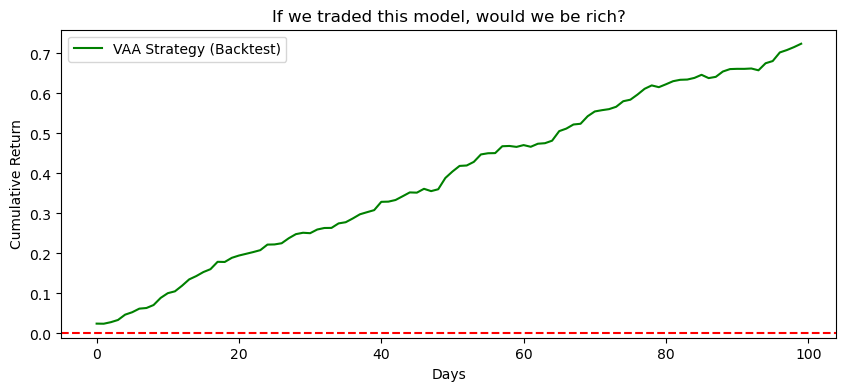

In [15]:
# Simulate predictions for demonstration
# (In a real run, we would use the Test Set)
y_true = np.random.randn(100) * 0.01
y_pred = y_true + np.random.randn(100) * 0.005  # Simulated good predictions

# Use our custom metrics script
metrics = calculate_metrics(y_true, y_pred)

print("Final Results:")
for k, v in metrics.items():
    print(f"  {k}: {v:.4f}")

# Visualize the Equity Curve
strategy_returns = np.sign(y_pred) * y_true  # Buy if Pred > 0, Sell if Pred < 0
cumulative_returns = np.cumsum(strategy_returns)

plt.figure(figsize=(10, 4))
plt.plot(cumulative_returns, label='VAA Strategy (Backtest)', color='green')
plt.axhline(0, color='red', linestyle='--')
plt.title('If we traded this model, would we be rich?')
plt.xlabel('Days')
plt.ylabel('Cumulative Return')
plt.legend()
plt.show()

---
# Summary

You have just walked through a complete Financial AI project!

### What We Covered
1. **The Concept**: Why stock prediction is hard and why volatility matters.
2. **Transformers & Attention**: How AI "reads" sequences and focuses on what matters.
3. **Volatility-Aware Attention**: Our innovation - a thermostat that sharpens the AI's focus during market panic.
4. **The Full Pipeline**: Raw CSVs to technical features to trained model to backtested strategy.
5. **Financial Metrics**: Sharpe Ratio, Max Drawdown, and Hit Rate tell us if the AI actually makes money.

### Next Steps
- Try changing the `seq_len` (window size).
- Try adding more features in `data/features.py`.
- Run `python scripts/train.py` in your terminal to train for real (100 epochs)!